# Problem Statement

**Currently, Churn of drivers is very high in OLA**.Losing drivers frequently impacts the morale of the organization and acquiring new drivers is more expensive than retaining existing ones.OLa wants to  to predict whether a driver will be leaving the company or not based on their attributes like

Demographics (city, age, gender etc.)

Tenure information (joining date, Last Date)

Historical data regarding the performance of the driver (Quarterly rating,
Monthly business acquired, grade, Income)


# Loading the Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import KNNImputer
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split, GridSearchCV

from imblearn.over_sampling import SMOTE

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
import xgboost as xgb

from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_auc_score, roc_curve

In [ ]:
df= pd.read_csv("ola_driver_scaler.csv")

In [ ]:
df.head(5)

,Unnamed: 0,MMM-YY,Driver_ID,Age,Gender,City,Education_Level,Income,Dateofjoining,LastWorkingDate,Joining Designation,Grade,Total Business Value,Quarterly Rating
0,0,01/01/19,1,28.0,0.0,C23,2,57387,24/12/18,NaN,1,1,2381060,2
1,1,02/01/19,1,28.0,0.0,C23,2,57387,24/12/18,NaN,1,1,-665480,2
2,2,03/01/19,1,28.0,0.0,C23,2,57387,24/12/18,03/11/19,1,1,0,2
3,3,11/01/20,2,31.0,0.0,C7,2,67016,11/06/20,NaN,2,2,0,1
4,4,12/01/20,2,31.0,0.0,C7,2,67016,11/06/20,NaN,2,2,0,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19104 entries, 0 to 19103
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0            19104 non-null  int64  
 1   MMM-YY                19104 non-null  object 
 2   Driver_ID             19104 non-null  int64  
 3   Age                   19043 non-null  float64
 4   Gender                19052 non-null  float64
 5   City                  19104 non-null  object 
 6   Education_Level       19104 non-null  int64  
 7   Income                19104 non-null  int64  
 8   Dateofjoining         19104 non-null  object 
 9   LastWorkingDate       1616 non-null   object 
 10  Joining Designation   19104 non-null  int64  
 11  Grade                 19104 non-null  int64  
 12  Total Business Value  19104 non-null  int64  
 13  Quarterly Rating      19104 non-null  int64  
dtypes: float64(2), int64(8), object(4)
memory usage: 2.0+ MB


**Column Profiling:**

MMMM-YY : Reporting Date (Monthly)

Driver_ID : Unique id for drivers

Age : Age of the driver

Gender : Gender of the driver – Male : 0, Female: 1

City : City Code of the driver

Education_Level : Education level – 0 for 10+ ,1 for 12+ ,2 for graduate

Income : Monthly average Income of the driver

Date Of Joining : Joining date for the driver

LastWorkingDate : Last date of working for the driver

Joining Designation : Designation of the driver at the time of joining

Grade : Grade of the driver at the time of reporting

Total Business Value : The total business value acquired by the driver in a
month (negative business indicates cancellation/refund or car EMI adjustments)

Quarterly Rating : Quarterly rating of the driver: 1,2,3,4,5 (higher is better)

In [ ]:
df1=df.copy()

In [ ]:
#Remove Unnamed column since we have Driver Id with unique values
df1.drop('Unnamed: 0',axis=1,inplace= True)

In [ ]:
df1= df1.rename(columns= {'MMM-YY':'Reporting_Date'})

In [ ]:
df = pd.DataFrame(columns=[
    "Reporting_Date", "Driver_ID", "Age", "Gender", "City",
    "Education_Level", "Income", "Dateofjoining", "LastWorkingDate",
    "Joining Designation", "Grade", "Total Business Value", "Quarterly Rating"
])

# Replace spaces with underscores in all column names
df1.columns = df.columns.str.replace(" ", "_").str.lower()

In [ ]:
df1["reporting_date"] = pd.to_datetime(df1["reporting_date"])
df1["dateofjoining"] = pd.to_datetime(df1["dateofjoining"])
df1["lastworkingdate"] = pd.to_datetime(df1["lastworkingdate"])

/tmp/ipython-input-1450250810.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df1["reporting_date"] = pd.to_datetime(df1["reporting_date"])
/tmp/ipython-input-1450250810.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df1["dateofjoining"] = pd.to_datetime(df1["dateofjoining"])
/tmp/ipython-input-1450250810.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df1["lastworkingdate"] = pd.to_datetime(df1["lastworkingdate"])


In [ ]:
df1.head()

,reporting_date,driver_id,age,gender,city,education_level,income,dateofjoining,lastworkingdate,joining_designation,grade,total_business_value,quarterly_rating
0,2019-01-01,1,28.0,0.0,C23,2,57387,2018-12-24,NaT,1,1,2381060,2
1,2019-02-01,1,28.0,0.0,C23,2,57387,2018-12-24,NaT,1,1,-665480,2
2,2019-03-01,1,28.0,0.0,C23,2,57387,2018-12-24,2019-03-11,1,1,0,2
3,2020-11-01,2,31.0,0.0,C7,2,67016,2020-11-06,NaT,2,2,0,1
4,2020-12-01,2,31.0,0.0,C7,2,67016,2020-11-06,NaT,2,2,0,1


In [ ]:
df1.shape

(19104, 13)

In [ ]:
df1.nunique()

,0
reporting_date,24
driver_id,2381
age,36
gender,2
city,29
education_level,3
income,2383
dateofjoining,869
lastworkingdate,493
joining_designation,5


In [ ]:
#determining null value count in columns

df1.isna().sum()

,0
reporting_date,0
driver_id,0
age,61
gender,52
city,0
education_level,0
income,0
dateofjoining,0
lastworkingdate,17488
joining_designation,0


# Handling Missing Values

KNN Imputer

In [ ]:
num_var= df1.select_dtypes(np.number)
num_var.columns

Index(['driver_id', 'age', 'gender', 'education_level', 'income',
       'joining_designation', 'grade', 'total_business_value',
       'quarterly_rating'],
      dtype='object')

In [ ]:
num_var.drop(['driver_id'],axis=1,inplace= True)

In [ ]:
imputer = KNNImputer(n_neighbors=5, weights='uniform', metric='nan_euclidean')
imputer.fit(num_var)
data_new = imputer.transform(num_var)

In [ ]:
data_new = pd.DataFrame(data_new)

In [ ]:
data_new.columns = num_var.columns

In [ ]:
data_new.isnull().sum()

,0
age,0
gender,0
education_level,0
income,0
joining_designation,0
grade,0
total_business_value,0
quarterly_rating,0


In [ ]:
resultant_columns = list(set(df1.columns).difference(set(num_var)))

resultant_columns

['reporting_date', 'city', 'driver_id', 'lastworkingdate', 'dateofjoining']

In [ ]:
new_df = pd.concat([data_new, df1[resultant_columns]], axis=1)

new_df.shape

(19104, 13)

In [ ]:
new_df.head()

,age,gender,education_level,income,joining_designation,grade,total_business_value,quarterly_rating,reporting_date,city,driver_id,lastworkingdate,dateofjoining
0,28.0,0.0,2.0,57387.0,1.0,1.0,2381060.0,2.0,2019-01-01,C23,1,NaT,2018-12-24
1,28.0,0.0,2.0,57387.0,1.0,1.0,-665480.0,2.0,2019-02-01,C23,1,NaT,2018-12-24
2,28.0,0.0,2.0,57387.0,1.0,1.0,0.0,2.0,2019-03-01,C23,1,2019-03-11,2018-12-24
3,31.0,0.0,2.0,67016.0,2.0,2.0,0.0,1.0,2020-11-01,C7,2,NaT,2020-11-06
4,31.0,0.0,2.0,67016.0,2.0,2.0,0.0,1.0,2020-12-01,C7,2,NaT,2020-11-06


# Data Preprocessing

**Feature Engineering**

In [ ]:
# Target Variable Creation: Having value 1 if the Last Working Date of the Driver is present else 0
target =  (df1.groupby('driver_id').agg({'lastworkingdate':'last'})['lastworkingdate'].isna()).reset_index()
target['lastworkingdate'].replace({True:0,False:1},inplace=True)
target.rename(columns={'lastworkingdate':'Target'},inplace=True)
target.head()

/tmp/ipython-input-621094649.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  target['lastworkingdate'].replace({True:0,False:1},inplace=True)
/tmp/ipython-input-621094649.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  target['lastworkingdate'].replace({True:0,False:1},inplace=True)


,driver_id,Target
0,1,1
1,2,0
2,4,1
3,5,1
4,6,0


In [ ]:
QR1 = (df1.groupby('driver_id').agg({'quarterly_rating': 'first'})['quarterly_rating']).reset_index()
QR2 = (df1.groupby('driver_id').agg({'quarterly_rating':'last'})['quarterly_rating']).reset_index()

In [ ]:
QR1.shape,QR2.shape

((2381, 2), (2381, 2))

In [ ]:
QR1.isna().sum(),QR2.isna().sum()

(driver_id           0
 quarterly_rating    0
 dtype: int64,
 driver_id           0
 quarterly_rating    0
 dtype: int64)

In [ ]:
target = target.merge(QR1,on ='driver_id')
target = target.merge(QR2,on ='driver_id')

In [ ]:
target['Rating_incr']=np.where(target['quarterly_rating_x'] < target['quarterly_rating_y'], 1,0)
target.head()


,driver_id,Target,quarterly_rating_x,quarterly_rating_y,Rating_incr
0,1,1,2,2,0
1,2,0,1,1,0
2,4,1,1,1,0
3,5,1,1,1,0
4,6,0,1,2,1


In [ ]:
# Income_incr: If the monthly income has increased for any driver then value 1 else 0
incm1 =  (df1.groupby('driver_id').agg({'income':'first'})['income']).reset_index()
incm2 = (df1.groupby('driver_id').agg({'income':'last'})['income']).reset_index()

In [ ]:
target = target.merge(incm1,on='driver_id')
target = target.merge(incm2,on='driver_id')

In [ ]:
target['income_incr'] = np.where(target['income_x'] < target['income_y'], 1,0)

In [ ]:
target2=target[['driver_id','Target','Rating_incr','income_incr']]

In [ ]:
target2.head()

,driver_id,Target,Rating_incr,income_incr
0,1,1,0,0
1,2,0,0,0
2,4,1,0,0
3,5,1,0,0
4,6,0,1,0


**Aggregation and Merger of Columns based on Driver_ID**

In [ ]:
df2=df1.copy()

In [ ]:
functions = {'reporting_date':'count',
             'age':'max',
             'gender':'last',
             'city':'last',
             'education_level':'last',
             'dateofjoining':'first',
             'lastworkingdate':'last',
             'grade':'last',
             'total_business_value':'sum',
             'income':'last',
             'joining_designation':'last',
             'quarterly_rating':'last'}
df2 = df2.groupby('driver_id').agg(functions).reset_index()
df2.rename(columns={'reporting_date':'reportings'},inplace=True)
df2 = df2.merge(target2,on='driver_id')

In [ ]:
df2.head()

,driver_id,reportings,age,gender,city,education_level,dateofjoining,lastworkingdate,grade,total_business_value,income,joining_designation,quarterly_rating,Target,Rating_incr,income_incr
0,1,3,28.0,0.0,C23,2,2018-12-24,2019-03-11,1,1715580,57387,1,2,1,0,0
1,2,2,31.0,0.0,C7,2,2020-11-06,NaT,2,0,67016,2,1,0,0,0
2,4,5,43.0,0.0,C13,2,2019-12-07,2020-04-27,2,350000,65603,2,1,1,0,0
3,5,3,29.0,0.0,C9,0,2019-01-09,2019-03-07,1,120360,46368,1,1,1,0,0
4,6,5,31.0,1.0,C11,1,2020-07-31,NaT,3,1265000,78728,3,2,0,1,0


There are 2381 rows and 15 columns signifying unique 2381 Driver ids

### Checking Null Values of the aggregated dataset

In [ ]:
df2.isna().sum()

,0
driver_id,0
reportings,0
age,0
gender,0
city,0
education_level,0
dateofjoining,0
lastworkingdate,765
grade,0
total_business_value,0


In [ ]:
df2[df2.duplicated()]

,driver_id,reportings,age,gender,city,education_level,dateofjoining,lastworkingdate,grade,total_business_value,income,joining_designation,quarterly_rating,Target,Rating_incr,income_incr


No Duplicate data observed

### Checking Outliers

In [ ]:
num_cols=['reportings','age','total_business_value','income']

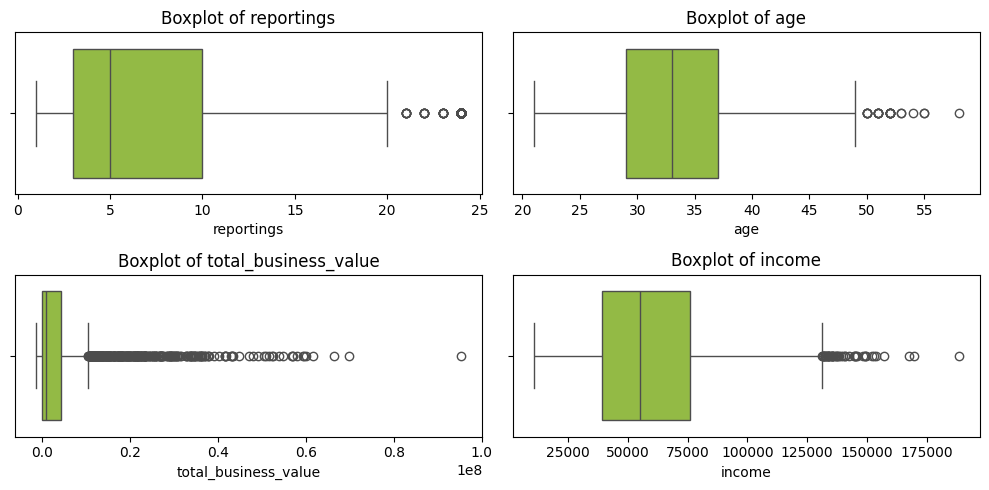

In [ ]:
fig = plt.figure(figsize=(10,5))
i=1
for col in num_cols:
  ax = plt.subplot(2,2,i)
  sns.boxplot(x=df2[col],color='yellowgreen')
  plt.title(f'Boxplot of {col}')
  i += 1

plt.tight_layout()
plt.show()

Although we have Outliers but we cannot remove/filter rows with otliers because the size of the dataset is very limited and we need the datapoints for better model prediction.

# Distribution of variables: Univariate and Bivariate Analysis

Statistical Summary

UniVariate Analysis

BiVariate Analysis

Impact of Each Feature on Churn


In [ ]:
df3=df2.copy()

In [ ]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2381 entries, 0 to 2380
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   driver_id             2381 non-null   int64         
 1   reportings            2381 non-null   int64         
 2   age                   2381 non-null   float64       
 3   gender                2381 non-null   float64       
 4   city                  2381 non-null   object        
 5   education_level       2381 non-null   int64         
 6   dateofjoining         2381 non-null   datetime64[ns]
 7   lastworkingdate       1616 non-null   datetime64[ns]
 8   grade                 2381 non-null   int64         
 9   total_business_value  2381 non-null   int64         
 10  income                2381 non-null   int64         
 11  joining_designation   2381 non-null   int64         
 12  quarterly_rating      2381 non-null   int64         
 13  Target            

In [ ]:
columns_to_convert=['reportings', 'gender', 'city', 'education_level',
 'grade', 'joining_designation', 'quarterly_rating',
 'Rating_incr', 'income_incr', 'Target']

In [ ]:
df3[columns_to_convert] = df3[columns_to_convert].apply(lambda x: x.astype('category'))

In [ ]:
df3.describe( include= 'all').T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
driver_id,2381.0,NaN,NaN,NaN,1397.559009,1.0,695.0,1400.0,2100.0,2788.0,806.161628
reportings,2381.0,24.0,5.0,309.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,2381.0,NaN,NaN,NaN,33.663167,21.0,29.0,33.0,37.0,58.0,5.983375
gender,2381.0,2.0,0.0,1404.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
city,2381,29,C20,152,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education_level,2381.0,3.0,2.0,802.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
dateofjoining,2381,NaN,NaN,NaN,2019-02-08 07:14:50.550189056,2013-04-01 00:00:00,2018-06-29 00:00:00,2019-07-21 00:00:00,2020-05-02 00:00:00,2020-12-28 00:00:00,NaN
lastworkingdate,1616,NaN,NaN,NaN,2019-12-21 20:59:06.534653440,2018-12-31 00:00:00,2019-06-06 00:00:00,2019-12-20 12:00:00,2020-07-03 00:00:00,2020-12-28 00:00:00,NaN
grade,2381.0,5.0,2.0,855.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
total_business_value,2381.0,NaN,NaN,NaN,4586741.822764,-1385530.0,0.0,817680.0,4173650.0,95331060.0,9127115.313446


## **For Categorical Features**

**Univariate Analysis**

In [ ]:
newcat_cols=['gender','education_level','grade','joining_designation','quarterly_rating','Rating_incr','income_incr','Target']


In [ ]:
for _ in newcat_cols:
    print()
    print(f'Total Unique Values in {_} column are :- {df2[_].nunique()}')
    print(f'Value counts in {_} column are :-\n {df2[_].value_counts(normalize=True)}')
    print()
    print('-'*120)


Total Unique Values in gender column are :- 2
Value counts in gender column are :-
 gender
0.0    0.589668
1.0    0.410332
Name: proportion, dtype: float64

------------------------------------------------------------------------------------------------------------------------

Total Unique Values in education_level column are :- 3
Value counts in education_level column are :-
 education_level
2    0.336833
1    0.333893
0    0.329273
Name: proportion, dtype: float64

------------------------------------------------------------------------------------------------------------------------

Total Unique Values in grade column are :- 5
Value counts in grade column are :-
 grade
2    0.359093
1    0.311214
3    0.261655
4    0.057959
5    0.010080
Name: proportion, dtype: float64

------------------------------------------------------------------------------------------------------------------------

Total Unique Values in joining_designation column are :- 5
Value counts in joining_designa

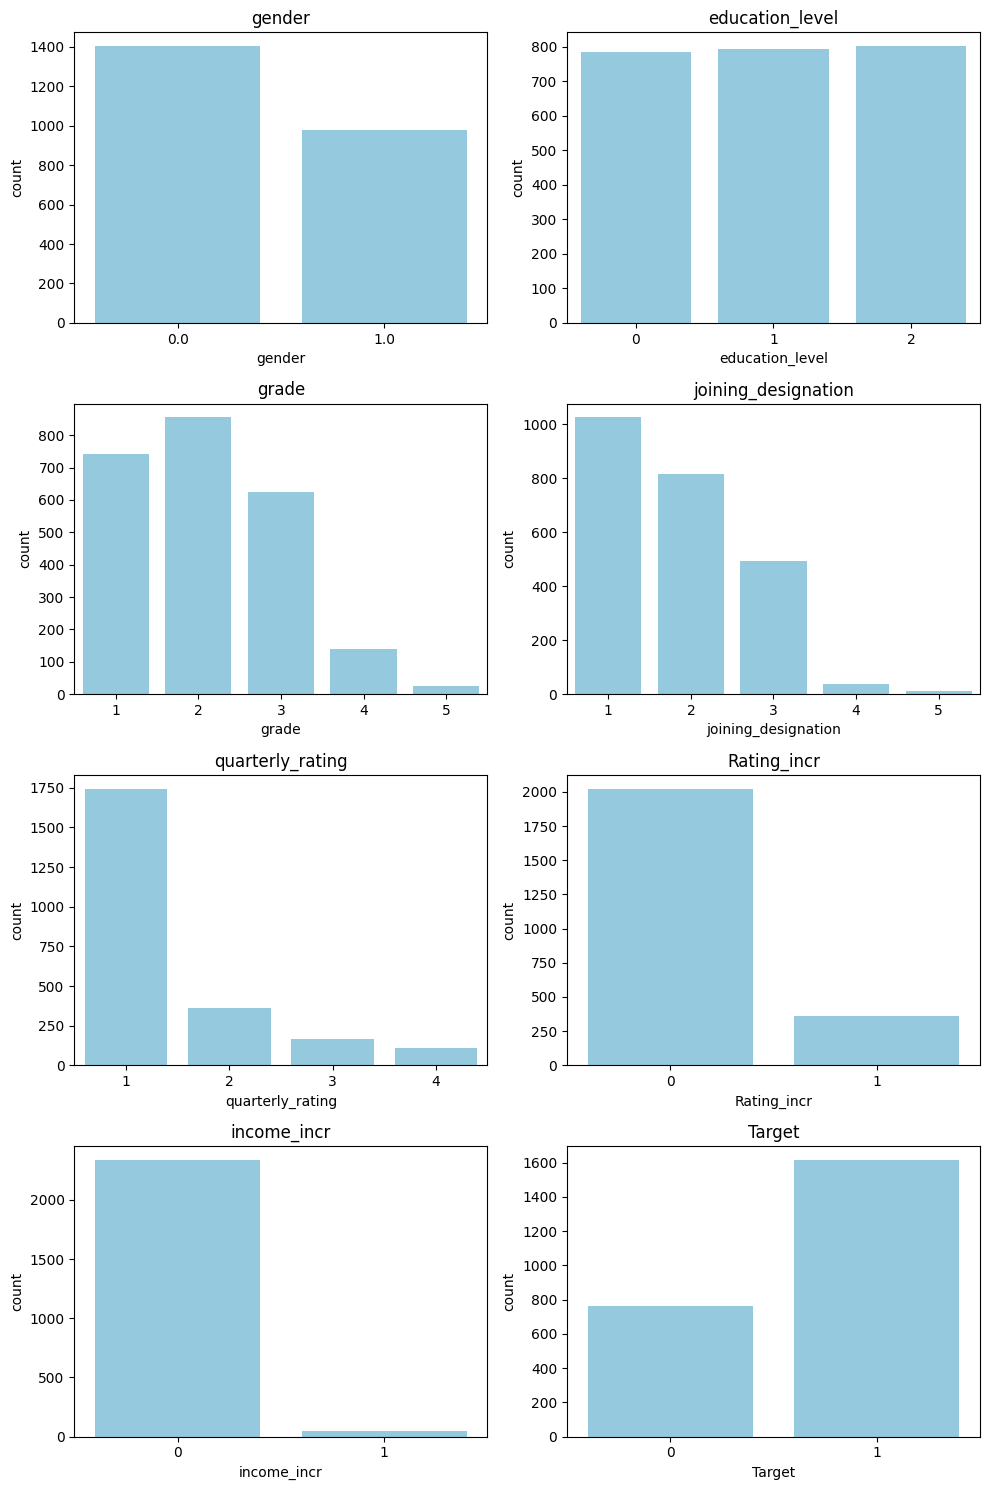

In [ ]:

plt.figure(figsize=(10,15))
i=1
for col in newcat_cols:
  ax=plt.subplot(4,2,i)
  sns.countplot(x=df2[col],color='skyblue')
  plt.title(f'{col}')
  i += 1

plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Distribution of City')

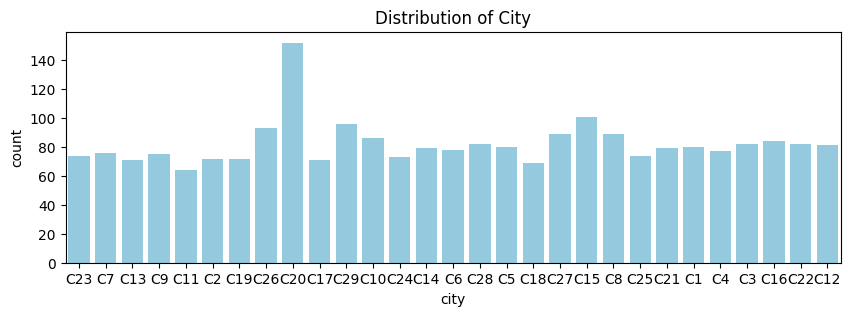

In [ ]:
plt.figure(figsize=(10,3))
sns.countplot(x=df2['city'],color='skyblue')
plt.title('Distribution of City')

 **Bivariate Analysis**

In [ ]:
categorical_cols = ['gender','education_level','grade','joining_designation','quarterly_rating','Rating_incr','income_incr']

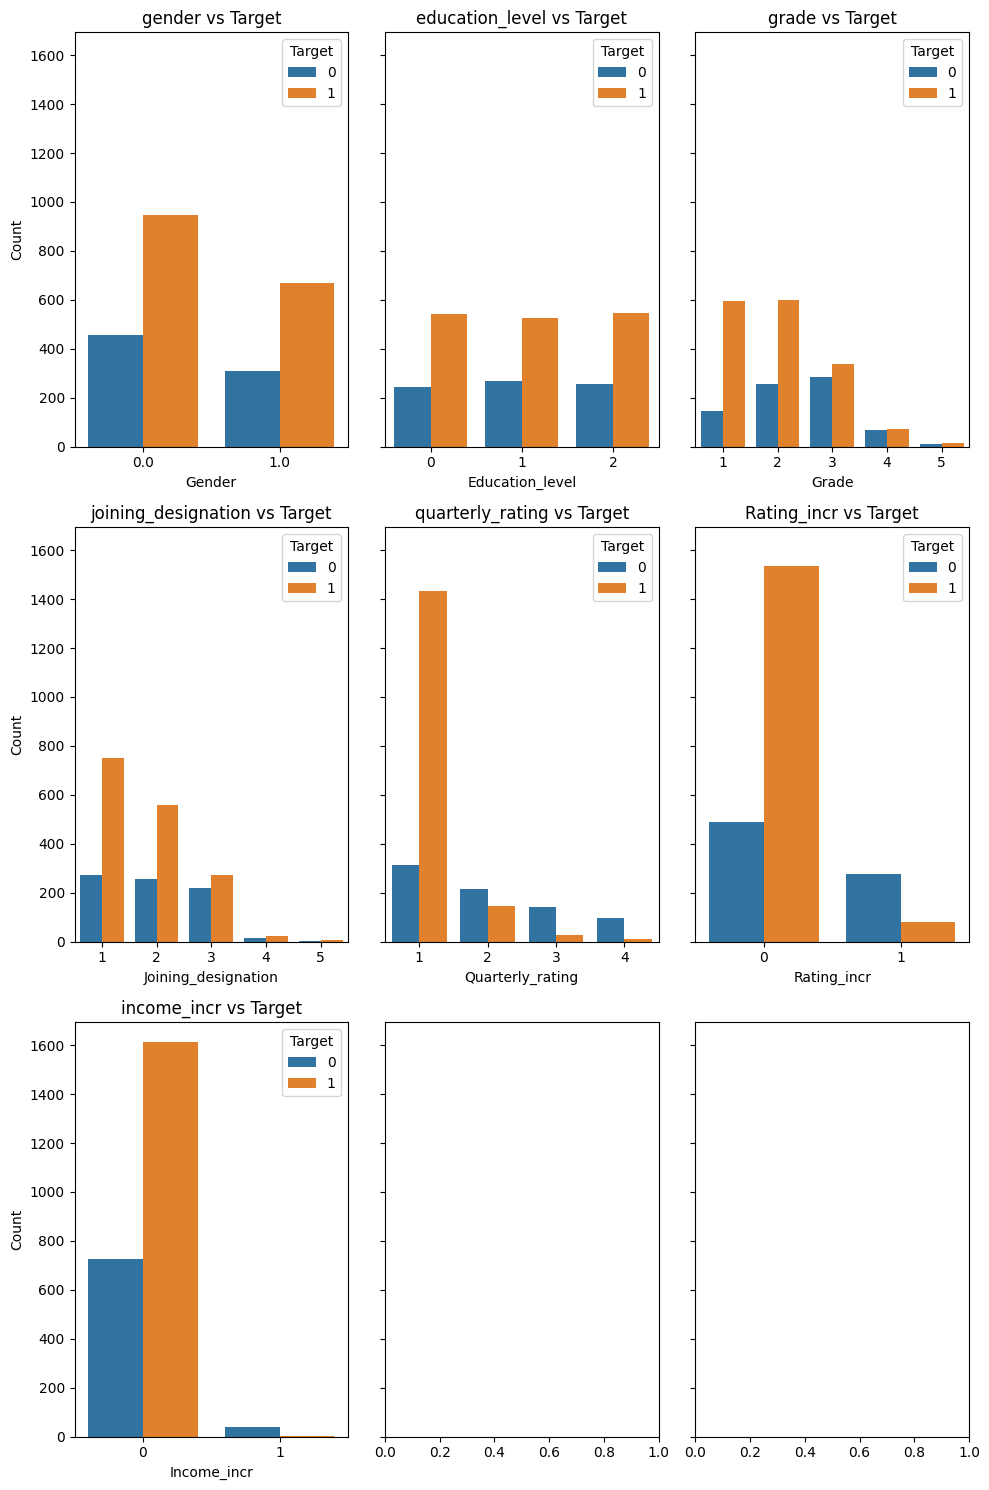

In [ ]:
rows = 3
cols = 3

fig, axes = plt.subplots(rows, cols, figsize=(10,15), sharey=True)

# Flatten axes into 1D for easy looping
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    sns.countplot(data=df2, x=col, hue='Target', ax=axes[i])
    axes[i].set_title(f"{col} vs Target")
    axes[i].set_xlabel(col.capitalize())
    axes[i].set_ylabel("Count")

plt.tight_layout()
plt.show()


**Total Business Value w.r.t City**

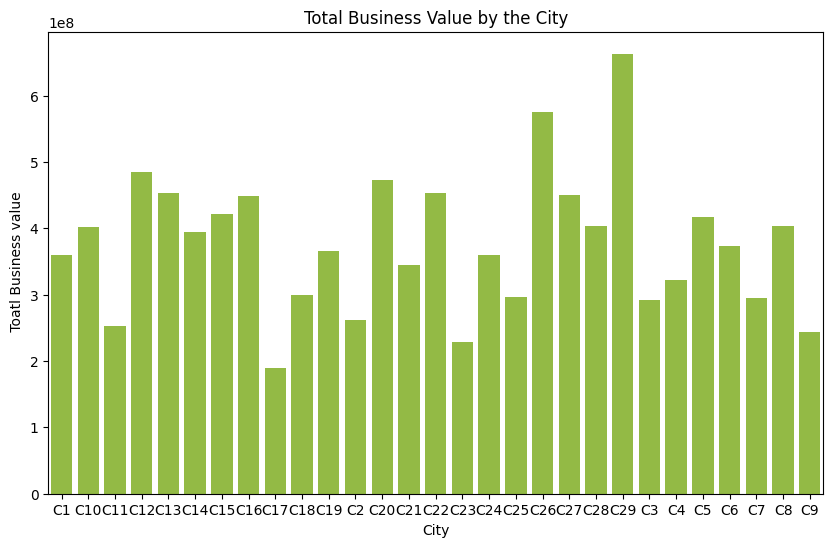

In [ ]:
city_tbv = df2.groupby("city")["total_business_value"].sum().reset_index()

#plot BV with respect to the city
plt.figure(figsize=(10,6))
sns.barplot(data=city_tbv, x= 'city', y = "total_business_value",color= "yellowgreen")

#add title and labels
plt.title('Total Business Value by the City')
plt.xlabel('City')
plt.ylabel(' Toatl Business value')
plt.show()


**Understanding the churn behaviour by City**

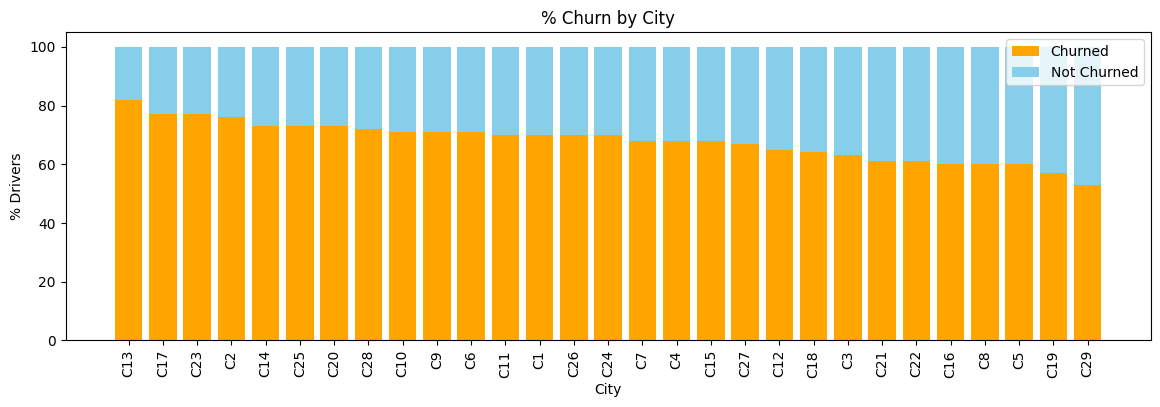

In [ ]:

    city = df2.pivot_table(index='city', columns='Target', aggfunc='size')
    city = city.div(city.sum(axis=1), axis=0).multiply(100).round()
    city.reset_index(inplace=True)
    city = city.sort_values(by=1, ascending=False)

    plt.figure(figsize=(14,4))
    plt.bar(city['city'], city[1], color='orange')
    plt.bar(city['city'], city[0], color='skyblue', bottom=city[1])

    # Labeling and titles
    plt.xlabel('City')
    plt.ylabel('% Drivers')
    plt.title(f'% Churn by City')
    plt.legend(['Churned', 'Not Churned'])
    plt.xticks(rotation=90)
    plt.show()

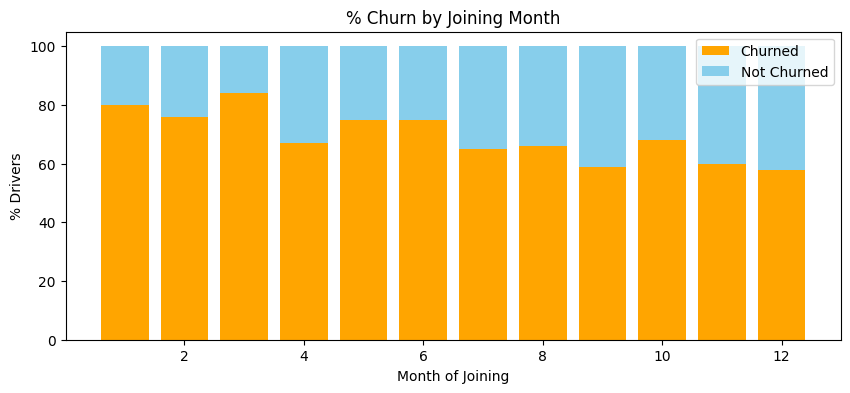

In [ ]:
    m = df2.pivot_table(index=df2['dateofjoining'].dt.month, columns='Target', aggfunc='size')
    m = m.div(m.sum(axis=1), axis=0).multiply(100).round()
    m.reset_index(inplace=True)
    #m = m.sort_values(by=1, ascending=False)

    plt.figure(figsize=(10,4))
    plt.bar(m['dateofjoining'], m[1], color='orange')
    plt.bar(m['dateofjoining'], m[0], color='skyblue', bottom=m[1])

    # Labeling and titles
    plt.xlabel('Month of Joining')
    plt.ylabel('% Drivers')
    plt.title(f'% Churn by Joining Month')
    plt.legend(['Churned', 'Not Churned'])
    plt.show()

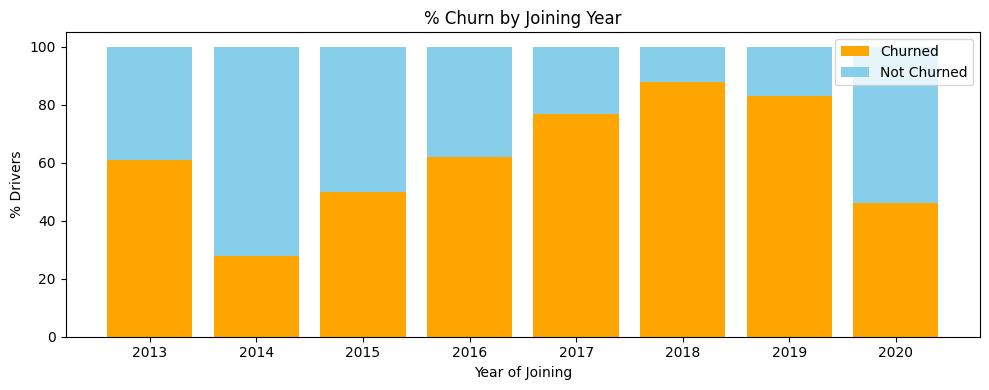

In [ ]:
    y = df2.pivot_table(index=df2['dateofjoining'].dt.year, columns='Target', aggfunc='size')
    y = y.div(y.sum(axis=1), axis=0).multiply(100).round()
    y.reset_index(inplace=True)

    plt.figure(figsize=(10,4))
    plt.bar(y['dateofjoining'], y[1], color='orange')
    plt.bar(y['dateofjoining'], y[0], color='skyblue', bottom=y[1])

    # Labeling and titles
    plt.xlabel('Year of Joining')
    plt.ylabel('% Drivers')
    plt.title(f'% Churn by Joining Year')
    plt.legend(['Churned', 'Not Churned'])
    plt.tight_layout()
    plt.show()

## **For Numerical Features**

In [ ]:
num_cols=['reportings','age','total_business_value','income']

/tmp/ipython-input-998374750.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Target', y=col, data=df2, ax=axes[i], palette='Set2')
/tmp/ipython-input-998374750.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Target', y=col, data=df2, ax=axes[i], palette='Set2')
/tmp/ipython-input-998374750.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Target', y=col, data=df2, ax=axes[i], palette='Set2')
/tmp/ipython-input-998374750.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0

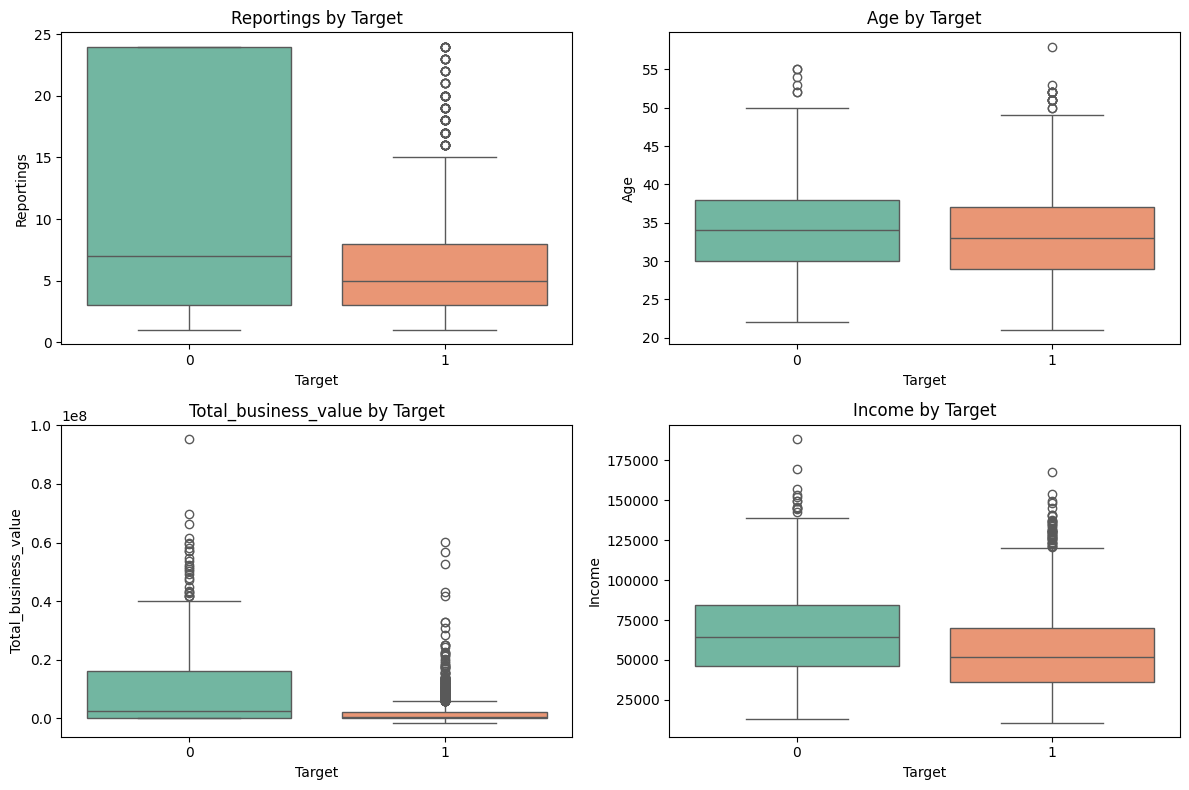

In [ ]:


# Flatten axes for easy looping
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(x='Target', y=col, data=df2, ax=axes[i], palette='Set2')
    axes[i].set_title(f'{col.capitalize()} by Target')
    axes[i].set_xlabel("Target")
    axes[i].set_ylabel(col.capitalize())

plt.tight_layout()
plt.show()

### Insights from Univariate and Bivariate Analysis

1: 67 % of the drivers have churned.

2: Drivers who had no Quarterly rating increment or Quaterly income increments have also churned the most.

3: Drivers whose Joining designation is lower or grade is lower are more likely to churn.

4: Total Business Value of Drivers is highest in C29 followed by C26

5: C20 is the city with highest number of drivers followed C15

6: Driver from city C13 has churned the most followed by C17 and C23

7: There is no effect of Gender and Education Level on Churn

8: There is no significant observation on churn w.r.t joining month

9: Almost 90% of the Drivers who joined in the year 2018 left OLA followed by 2019 and 2017

10: People who have churned have reported very less average Business value, receive very less income and have reported fewer times


In [ ]:
numerical_df2 = df2.select_dtypes(include=['int64', 'float64'])

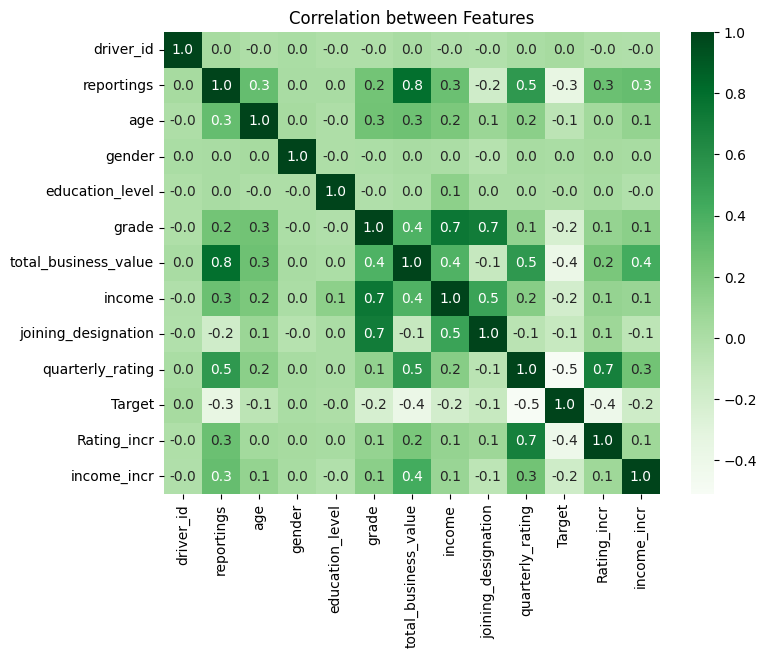

In [ ]:

#Correlation among features
plt.figure(figsize=(8,6))
sns.heatmap(numerical_df2.corr(), annot=True, fmt=".1f",cmap='Greens')
plt.title('Correlation between Features')
plt.show()

**Highlights:**

Reportings shows a strong positive correlation with Total Business Value.

Quarterly Rating and Rating_incr are highly correlated, which is expected.

Grade has a strong positive correlation with both Income and Joining Designation.

Based on these observations, we may consider dropping some of these features.

However, it is important to note that multicollinearity can also result from the combined effect of multiple features, not only from pairwise correlations.

# Data Preparation for Modeling

Encoding
Scaling
Train Test Split
Class Imbalance- SMOTE

In [ ]:
df_prep=df2.drop(columns=['driver_id','lastworkingdate'],axis=1)

In [ ]:
df_prep['Month']=df_prep['dateofjoining'].dt.month
df_prep['Year']=df_prep['dateofjoining'].dt.year

In [ ]:
df_prep.drop('dateofjoining',axis=1,inplace=True)

## One Hot encoding

In [ ]:
df_encoded = pd.get_dummies(df_prep, columns=['city', 'gender'], drop_first=True) * 1


In [ ]:
df_encoded.head()

,reportings,age,education_level,grade,total_business_value,income,joining_designation,quarterly_rating,Target,Rating_incr,...,city_C28,city_C29,city_C3,city_C4,city_C5,city_C6,city_C7,city_C8,city_C9,gender_1.0
0,3,28.0,2,1,1715580,57387,1,2,1,0,...,0,0,0,0,0,0,0,0,0,0
1,2,31.0,2,2,0,67016,2,1,0,0,...,0,0,0,0,0,0,1,0,0,0
2,5,43.0,2,2,350000,65603,2,1,1,0,...,0,0,0,0,0,0,0,0,0,0
3,3,29.0,0,1,120360,46368,1,1,1,0,...,0,0,0,0,0,0,0,0,1,0
4,5,31.0,1,3,1265000,78728,3,2,0,1,...,0,0,0,0,0,0,0,0,0,1


In [ ]:
df_encoded.shape

(2381, 42)

## Train Test Split

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
#Prepare X and y dataset i.e. independent and dependent datasets

X = df_encoded.drop(['Target'], axis=1)
y = df_encoded['Target']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Scaling

In [ ]:
from sklearn.preprocessing import MinMaxScaler

In [ ]:
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

## check Class Imbalance

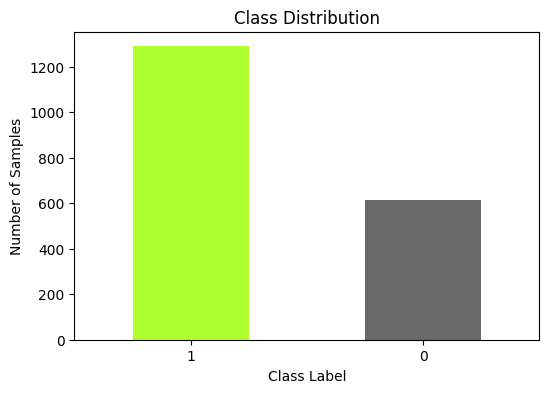

Class Ratio (Majority / Minority): 2.10


In [ ]:
# Count class frequencies
class_counts = y_train.value_counts()

# Create a bar chart
plt.figure(figsize=(6, 4))
class_counts.plot(kind='bar', color=['greenyellow', 'dimgrey'])
plt.xlabel('Class Label')
plt.ylabel('Number of Samples')
plt.title('Class Distribution')
plt.xticks(rotation=0)  # Rotate x-axis labels for better readability
plt.show()

# Print class ratio (optional)
print(f"Class Ratio (Majority / Minority): {class_counts.iloc[0] / class_counts.iloc[1]:.2f}")

Since we have observed Class imbalance, we need to perform resampling of data to get better model performance.

In [ ]:
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

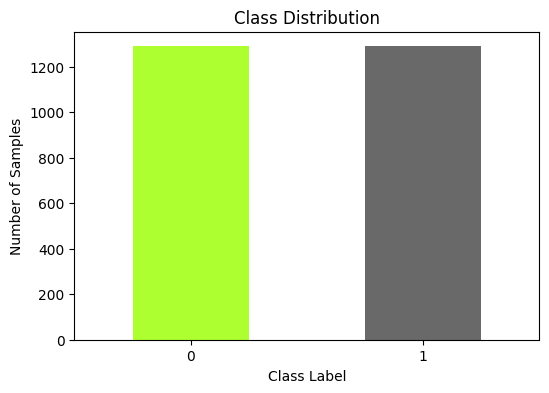

Class Ratio (Majority / Minority): 1.00


In [ ]:
# Count class frequencies
class_counts = y_train_res.value_counts()

# Create a bar chart
plt.figure(figsize=(6, 4))
class_counts.plot(kind='bar', color=['greenyellow', 'dimgrey'])
plt.xlabel('Class Label')
plt.ylabel('Number of Samples')
plt.title('Class Distribution')
plt.xticks(rotation=0)  # Rotate x-axis labels for better readability
plt.show()

# Print class ratio (optional)
print(f"Class Ratio (Majority / Minority): {class_counts.iloc[0] / class_counts.iloc[1]:.2f}")

# Model Building

## Base Model:

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score,log_loss,accuracy_score

In [ ]:
# Baseline RF with default params
rf_base = RandomForestClassifier(random_state=42)

In [ ]:
rf_base.fit(X_train_res,y_train_res)

RandomForestClassifier(random_state=42)

In [ ]:

y_pred_base = rf_base.predict(X_test)
y_prob_base = rf_base.predict_proba(X_test)[:,1]


print("Baseline Test Accuracy:", accuracy_score(y_test, y_pred_base))
print("Baseline ROC AUC:", roc_auc_score(y_test, y_prob_base))
print("Baseline Log Loss:", log_loss(y_test, y_prob_base))

Baseline Test Accuracy: 0.31446540880503143
Baseline ROC AUC: 0.503190621814475
Baseline Log Loss: 1.2718670235124276


The Base Model Accuracy is very Poor.

## Ensemble Learning: Bagging (Random Forest Classifier)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
import time

In [ ]:
params = {"max_depth":[7,10,15],
             "n_estimators":[100,200,300,400],
             "max_features":[4,7,10],
             "ccp_alpha":[0.0005,0.00075,0.001]}

In [ ]:

grid_search = GridSearchCV(estimator=RandomForestClassifier(random_state=42), param_grid=params, cv=5, n_jobs=-1, verbose=2)

# Measure the time taken to fit the model
start_time = time.time()
grid_search.fit(X_train_res, y_train_res)
end_time = time.time()

print("Best parameters found by GridSearchCV:", grid_search.best_params_)
print(f"Total training time: {end_time - start_time:.2f} seconds")

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best parameters found by GridSearchCV: {'ccp_alpha': 0.0005, 'max_depth': 15, 'max_features': 7, 'n_estimators': 200}
Total training time: 548.51 seconds


In [ ]:
# Retrieve the best model (estimator)
best_model = grid_search.best_estimator_

# Make predictions on the test set
y_train_pred = best_model.predict(X_train_res)
y_test_pred = best_model.predict(X_test_scaled)

# Evaluate the model
# Accuracy
train_accuracy = accuracy_score(y_train_res, y_train_pred)
print(f"Training Accuracy: {train_accuracy:.2f}")

test_accuracy = accuracy_score(y_test, y_test_pred)
print(f"Test Accuracy: {test_accuracy:.2f}")

Training Accuracy: 0.98
Test Accuracy: 0.92


In [ ]:
grid_search.best_score_

np.float64(0.9387295853089486)

**Confusion Matrix Report**

In [ ]:
conf_matrix = confusion_matrix(y_test, y_test_pred)
print("Confusion Matrix:")
print(conf_matrix)

Confusion Matrix:
[[129  21]
 [ 16 311]]


In [ ]:
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.89      0.86      0.87       150
           1       0.94      0.95      0.94       327

    accuracy                           0.92       477
   macro avg       0.91      0.91      0.91       477
weighted avg       0.92      0.92      0.92       477



**Feature Importance**

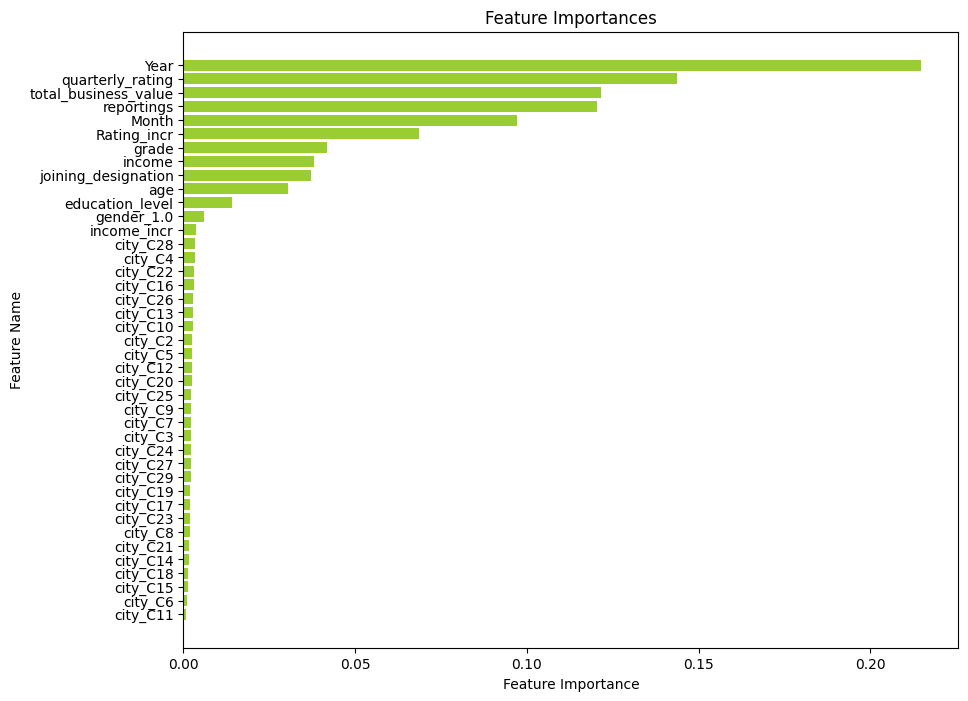

In [ ]:
feature_importances = best_model.feature_importances_

# Assuming X_train_res is your training data
# Assuming column_names is a list containing the names of your features
# You may obtain column_names from your DataFrame if you used one initially

# Create a dictionary to store feature names and their importances
feature_importance_dict = dict(zip(X_train_res.columns, feature_importances))

# Sort the dictionary by importance values in descending order
sorted_feature_importance = sorted(feature_importance_dict.items(), key=lambda x: x[1], reverse=True)

# Extract feature names and importances
sorted_feature_names = [x[0] for x in sorted_feature_importance]
sorted_importances = [x[1] for x in sorted_feature_importance]

# Plot feature importances
plt.figure(figsize=(10, 8))
plt.barh(sorted_feature_names, sorted_importances,color='yellowgreen')
plt.xlabel('Feature Importance')
plt.ylabel('Feature Name')
plt.title('Feature Importances')
plt.gca().invert_yaxis()  # Invert y-axis to show highest importance at the top
plt.show()

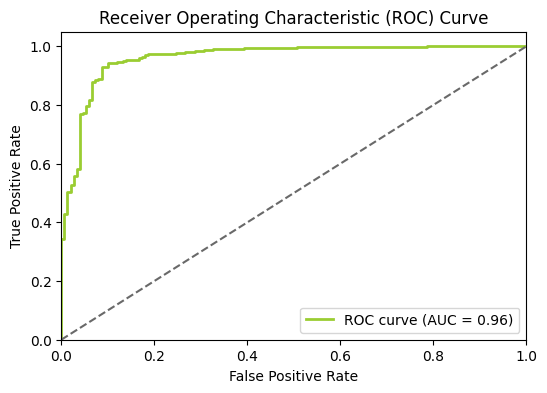

In [ ]:
# Make predictions on the test set
y_pred_proba = best_model.predict_proba(X_test_scaled)[:, 1]

# Compute ROC curve and ROC-AUC score
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = roc_auc_score(y_test, y_pred_proba)

# Plot ROC curve
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, color='yellowgreen', lw=2, label='ROC curve (AUC = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='dimgrey', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

In [ ]:
from sklearn.metrics import precision_recall_curve,auc

In [ ]:
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba)

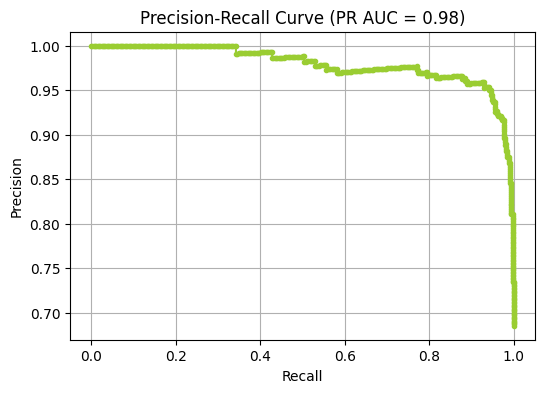

In [ ]:

pr_auc = auc(recall, precision)

# Plot the precision-recall curve
plt.figure(figsize=(6, 4))
plt.plot(recall, precision, marker='.',color='yellowgreen')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (PR AUC = {:.2f})'.format(pr_auc))
plt.grid(True)

# Annotate the PR AUC value on the plot
#plt.text(0.7, 0.2, 'PR AUC = {:.2f}'.format(pr_auc), fontsize=12)

plt.show()

## Ensemble Learning: Boosting

In [ ]:
import lightgbm as lgb

In [ ]:
# Configure LightGBM to suppress warnings
model = lgb.LGBMClassifier(silent=True, verbose=-1)

In [ ]:
# Define the grid of parameters to search
gridParams = {
    'learning_rate': [0.1, 0.3, 0.5],
    'boosting_type': ['gbdt'],
    'objective': ['binary'],
    'max_depth': [5, 6, 7, 8],
    'colsample_bytree': [0.5, 0.7],
    'subsample': [0.5, 0.7]
      }
# Setup GridSearchCV
grid = GridSearchCV(estimator=model, param_grid=gridParams, cv=3, scoring='neg_log_loss',verbose= False)

start_time=time.time()
grid.fit(X_train_res, y_train_res)
end_time=time.time()

# Print the best parameters found
print("Best parameters found: ", grid.best_params_)
# Best score
print("Best log loss: ", -grid.best_score_)
print(f"Total training time: {end_time - start_time:.2f} seconds")

Best parameters found:  {'boosting_type': 'gbdt', 'colsample_bytree': 0.7, 'learning_rate': 0.1, 'max_depth': 5, 'objective': 'binary', 'subsample': 0.5}
Best log loss:  0.17414219327775993
Total training time: 15.98 seconds


In [ ]:
# Retrieve the best model (estimator)
best_model = grid.best_estimator_

# Make predictions on the test set
y_train_pred = best_model.predict(X_train_res)
y_test_pred = best_model.predict(X_test_scaled)

# Evaluate the model
# Accuracy
train_accuracy = accuracy_score(y_train_res, y_train_pred)
print(f"Training Accuracy: {train_accuracy:.2f}")

test_accuracy = accuracy_score(y_test, y_test_pred)
print(f"Test Accuracy: {test_accuracy:.2f}")

Training Accuracy: 0.98
Test Accuracy: 0.92


**Observations :**

A log loss of 0.238 indicates that the model’s predicted probabilities are quite close to the actual outcomes, suggesting that the probability estimates are reasonably accurate.

A training accuracy of 96% shows that the model correctly classifies 96% of the samples in the training set, meaning it has effectively learned the patterns in the training data.

A test accuracy of 90% demonstrates that the model correctly predicts 90% of the samples in the test set, indicating strong performance on unseen data and good generalization.

**Confusion Matrix / Classification Report**

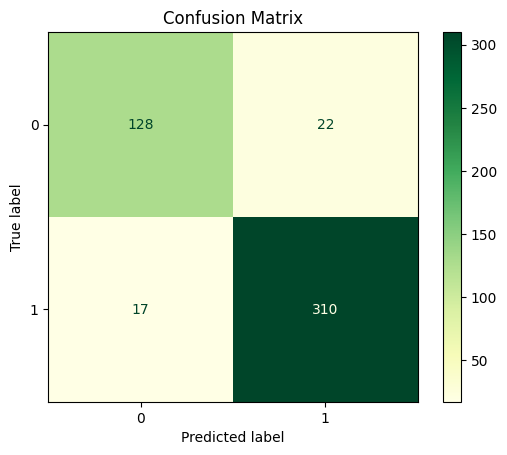

In [ ]:
conf_matrix = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(conf_matrix)
cmap = plt.cm.YlGn
disp.plot(cmap=cmap)
plt.title('Confusion Matrix')
plt.show()

In [ ]:
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.88      0.85      0.87       150
           1       0.93      0.95      0.94       327

    accuracy                           0.92       477
   macro avg       0.91      0.90      0.90       477
weighted avg       0.92      0.92      0.92       477



**Feature Importance**

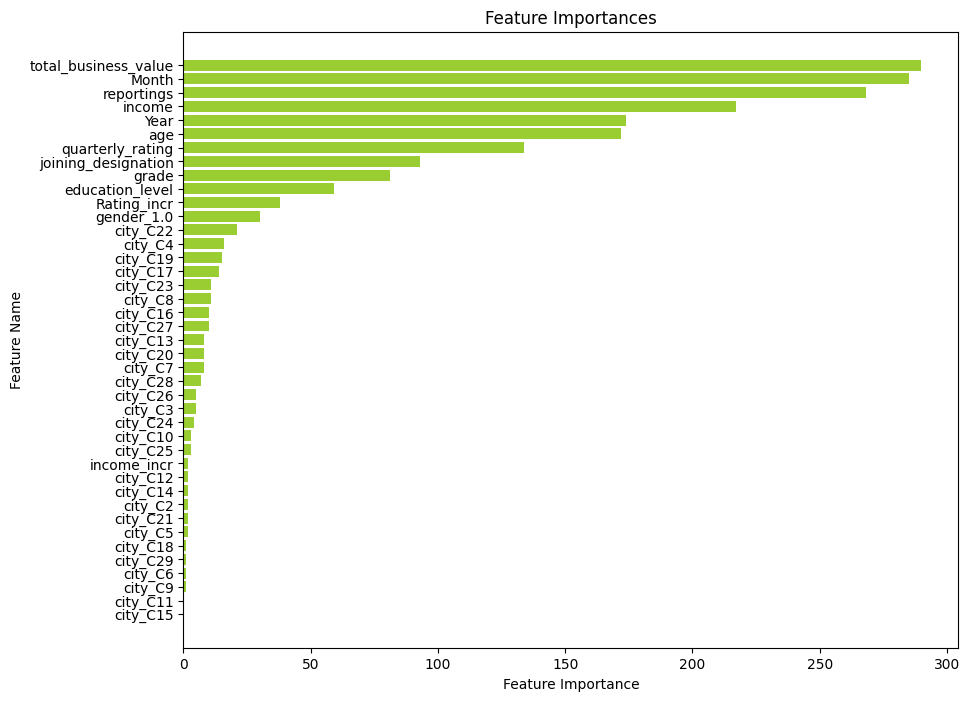

In [ ]:
feature_importances = best_model.feature_importances_

# Assuming X_train_res is your training data
# Assuming column_names is a list containing the names of your features
# You may obtain column_names from your DataFrame if you used one initially

# Create a dictionary to store feature names and their importances
feature_importance_dict = dict(zip(X_train_res.columns, feature_importances))

# Sort the dictionary by importance values in descending order
sorted_feature_importance = sorted(feature_importance_dict.items(), key=lambda x: x[1], reverse=True)

# Extract feature names and importances
sorted_feature_names = [x[0] for x in sorted_feature_importance]
sorted_importances = [x[1] for x in sorted_feature_importance]

# Plot feature importances
plt.figure(figsize=(10, 8))
plt.barh(sorted_feature_names, sorted_importances,color='yellowgreen')
plt.xlabel('Feature Importance')
plt.ylabel('Feature Name')
plt.title('Feature Importances')
plt.gca().invert_yaxis()  # Invert y-axis to show highest importance at the top
plt.show()

**Observations:**

Total Business Value is the most important feature followed by Reportings and Income
City is least important followed by Income_increment and Gender

ROC Curve & AUC

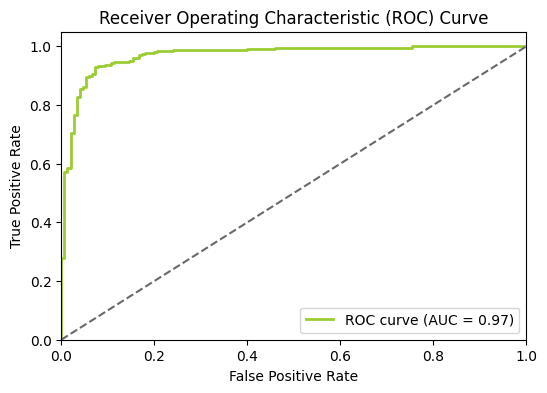

In [ ]:
import warnings
warnings.filterwarnings("ignore")
# Make predictions on the test set
y_pred_proba = best_model.predict_proba(X_test_scaled)[:, 1]

# Compute ROC curve and ROC-AUC score
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = roc_auc_score(y_test, y_pred_proba)

# Plot ROC curve
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, color='yellowgreen', lw=2, label='ROC curve (AUC = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='dimgrey', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

An AUC of 0.95 indicates that the binary classification model has outstanding ability to discriminate between classes. It achieves high true positive rates while keeping false positive rates low across various thresholds, demonstrating that the model effectively distinguishes between positive and negative samples. This makes it highly reliable for classification tasks.

**Precision Recall Curve**

In [ ]:
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba)

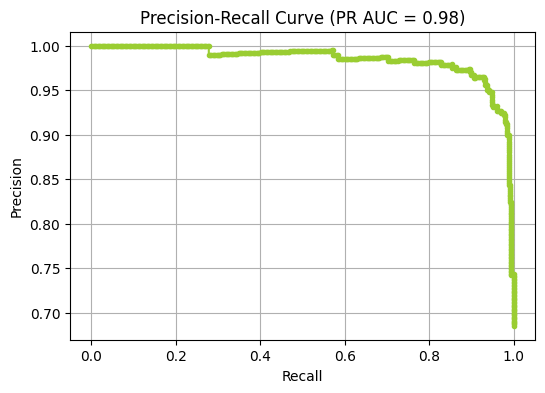

In [ ]:
pr_auc = auc(recall, precision)
# Plot the precision-recall curve
plt.figure(figsize=(6, 4))
plt.plot(recall, precision, marker='.',color='yellowgreen')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (PR AUC = {:.2f})'.format(pr_auc))
plt.grid(True)

plt.show()

**Observations :**

A PR AUC of 0.97 indicates that the binary classification model performs exceptionally well in balancing precision and recall.

It shows that the model maintains high precision (proportion of true positives among predicted positives) and high recall (proportion of true positives among actual positives) across different thresholds.

Such a high PR AUC suggests that the model makes very few false positive and false negative predictions, making it highly reliable, especially in scenarios where both precision and recall are critical.

# **Insights :**

1: Males are higher in ratio than females among Drivers

2: Hardly 2% of the Drivers got Increment in Income

3: Almost 77% of the Drivers who did not get any increase in Rating left the company

4: Both Random Forest and Light GBM shows good Training and test accuarcy , displaying the fact that bothe models are good enough for identifying drivers who are going to leave the company. This might help to take neccessary preventive actions.

5:The ROC AUc curve as well as PR Recall curve also explain good classification ability of the models with Area under the curve being >0.97

6: Some of the important Features which contributes most towards the model performance are : total_business_value ,reportings,month, year, income,age, quaterly rating, joining_designation etc

7: there seesm to be class Imbalance and therefore we have used Resampling method of SMOTE for Model prediction in order to avoid any bias in the data.

8: Total Business Value of Drivers is highest in city C29 followed by C26.

9: 67 % of the drivers have churned.

10: Drivers who had no Quarterly rating increment or Quaterly income increments have also churned the most.

11: Drivers whose Joining designation is lower or grade is lower are more likely to churn.

12: The precision and recall are quite high i.e. >90% for both the algorithms which explains the fact that the models are able to predict the churn rate in the best way possible (low False positives and False Negatives in the predictions)

13: The drivers who are most likely to churn are the one with low income and having contributed very low to total business Value generated.

# **Recommendations**:

1: **Training and Development**

Driver Training Programs:

Target Audience: Drivers with Grade 2 and those in high-churn categories.

Content: Improve driving skills, customer service, and adherence to safety protocols.

Objective: Enhance performance and reduce churn rates.

2: **Incentive Schemes**
Performance-based Incentives:

Performance-based bonuses: Reward drivers with high ratings, trip completions, or low cancellation rates.

Guaranteed minimum earnings: Offer daily/weekly guarantees during low-demand periods to reduce income uncertainty.

Flexible commission structures: Introduce higher commission for peak hours or high-demand zones

Focus: Encourage retention, especially for drivers in high-churn cities.

3: **Continuous Monitoring and Feedback**
Feedback Mechanisms:

Driver Surveys: Regularly collect feedback from drivers about their experiences, challenges, and suggestions.

Frequency: Quarterly surveys and feedback sessions.

Customer Feedback: Gather customer reviews and ratings to identify areas for improvement.

Integration: Use feedback to refine training programs and operational strategies.

4: **Operational Improvements**

Flexible work schedules: Allow drivers to choose shifts according to their convenience.

Reduce platform friction: Optimize app usability, reduce trip cancellation complexity, and provide better support for complaints.

Dynamic incentives: Use predictive insights from your model to proactively target at-risk drivers with incentives or support.

5: **Safety and Wellbeing**

Health & safety initiatives: Provide access to insurance, medical support, or safety measures for drivers.

Driver wellness programs: Offer financial literacy workshops, mental health support, or stress management programs.

6: **Reduction of driver Attrition costs** : The model helps predict the True Positives with a high Recall and hence can help reduce the driver attrition costs which involves a lot of things in terms money invested on hiring, trainings and health & wellbeings of drivers.

7: **Increase Driver Lifetime Value (DLV)**

Current issue: High churn shortens driver tenure, reducing long-term revenue.

Recommendation: Focus retention strategies on drivers with historically higher earnings per trip/hour.